In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\User\Downloads\Depression Data.csv")
df.head()

,1. Age,2. Gender,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


In [10]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    '1. Age': 'Age',
    '2. Gender': 'Gender',
    '5. Academic Year': 'Academic_Year',
    '6. Current CGPA': 'CGPA',
    '7. Did you receive a waiver or scholarship at your university?': 'Scholarship',
    'Depression Label': 'Depression'
})

In [11]:
df.drop(['Depression Value', 'Anxiety Label', 'Stress Label'], axis=1, inplace=True)

In [12]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 34 columns):
 #   Column                                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                                --------------  ----- 
 0   Age                                                                                                                                                                   1977 non-null   object
 1   Gender                                                                                                                                                                1971 non-null   object
 2   Academic_Year                                                                                                   

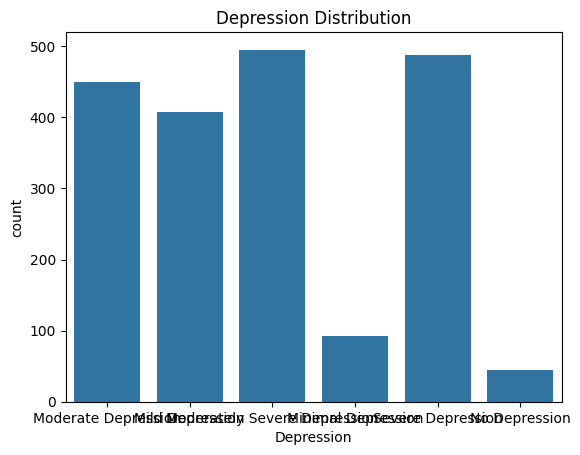

In [13]:
sns.countplot(x='Depression', data=df)
plt.title("Depression Distribution")
plt.show()

In [14]:
df.fillna(df.mode().iloc[0], inplace=True)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

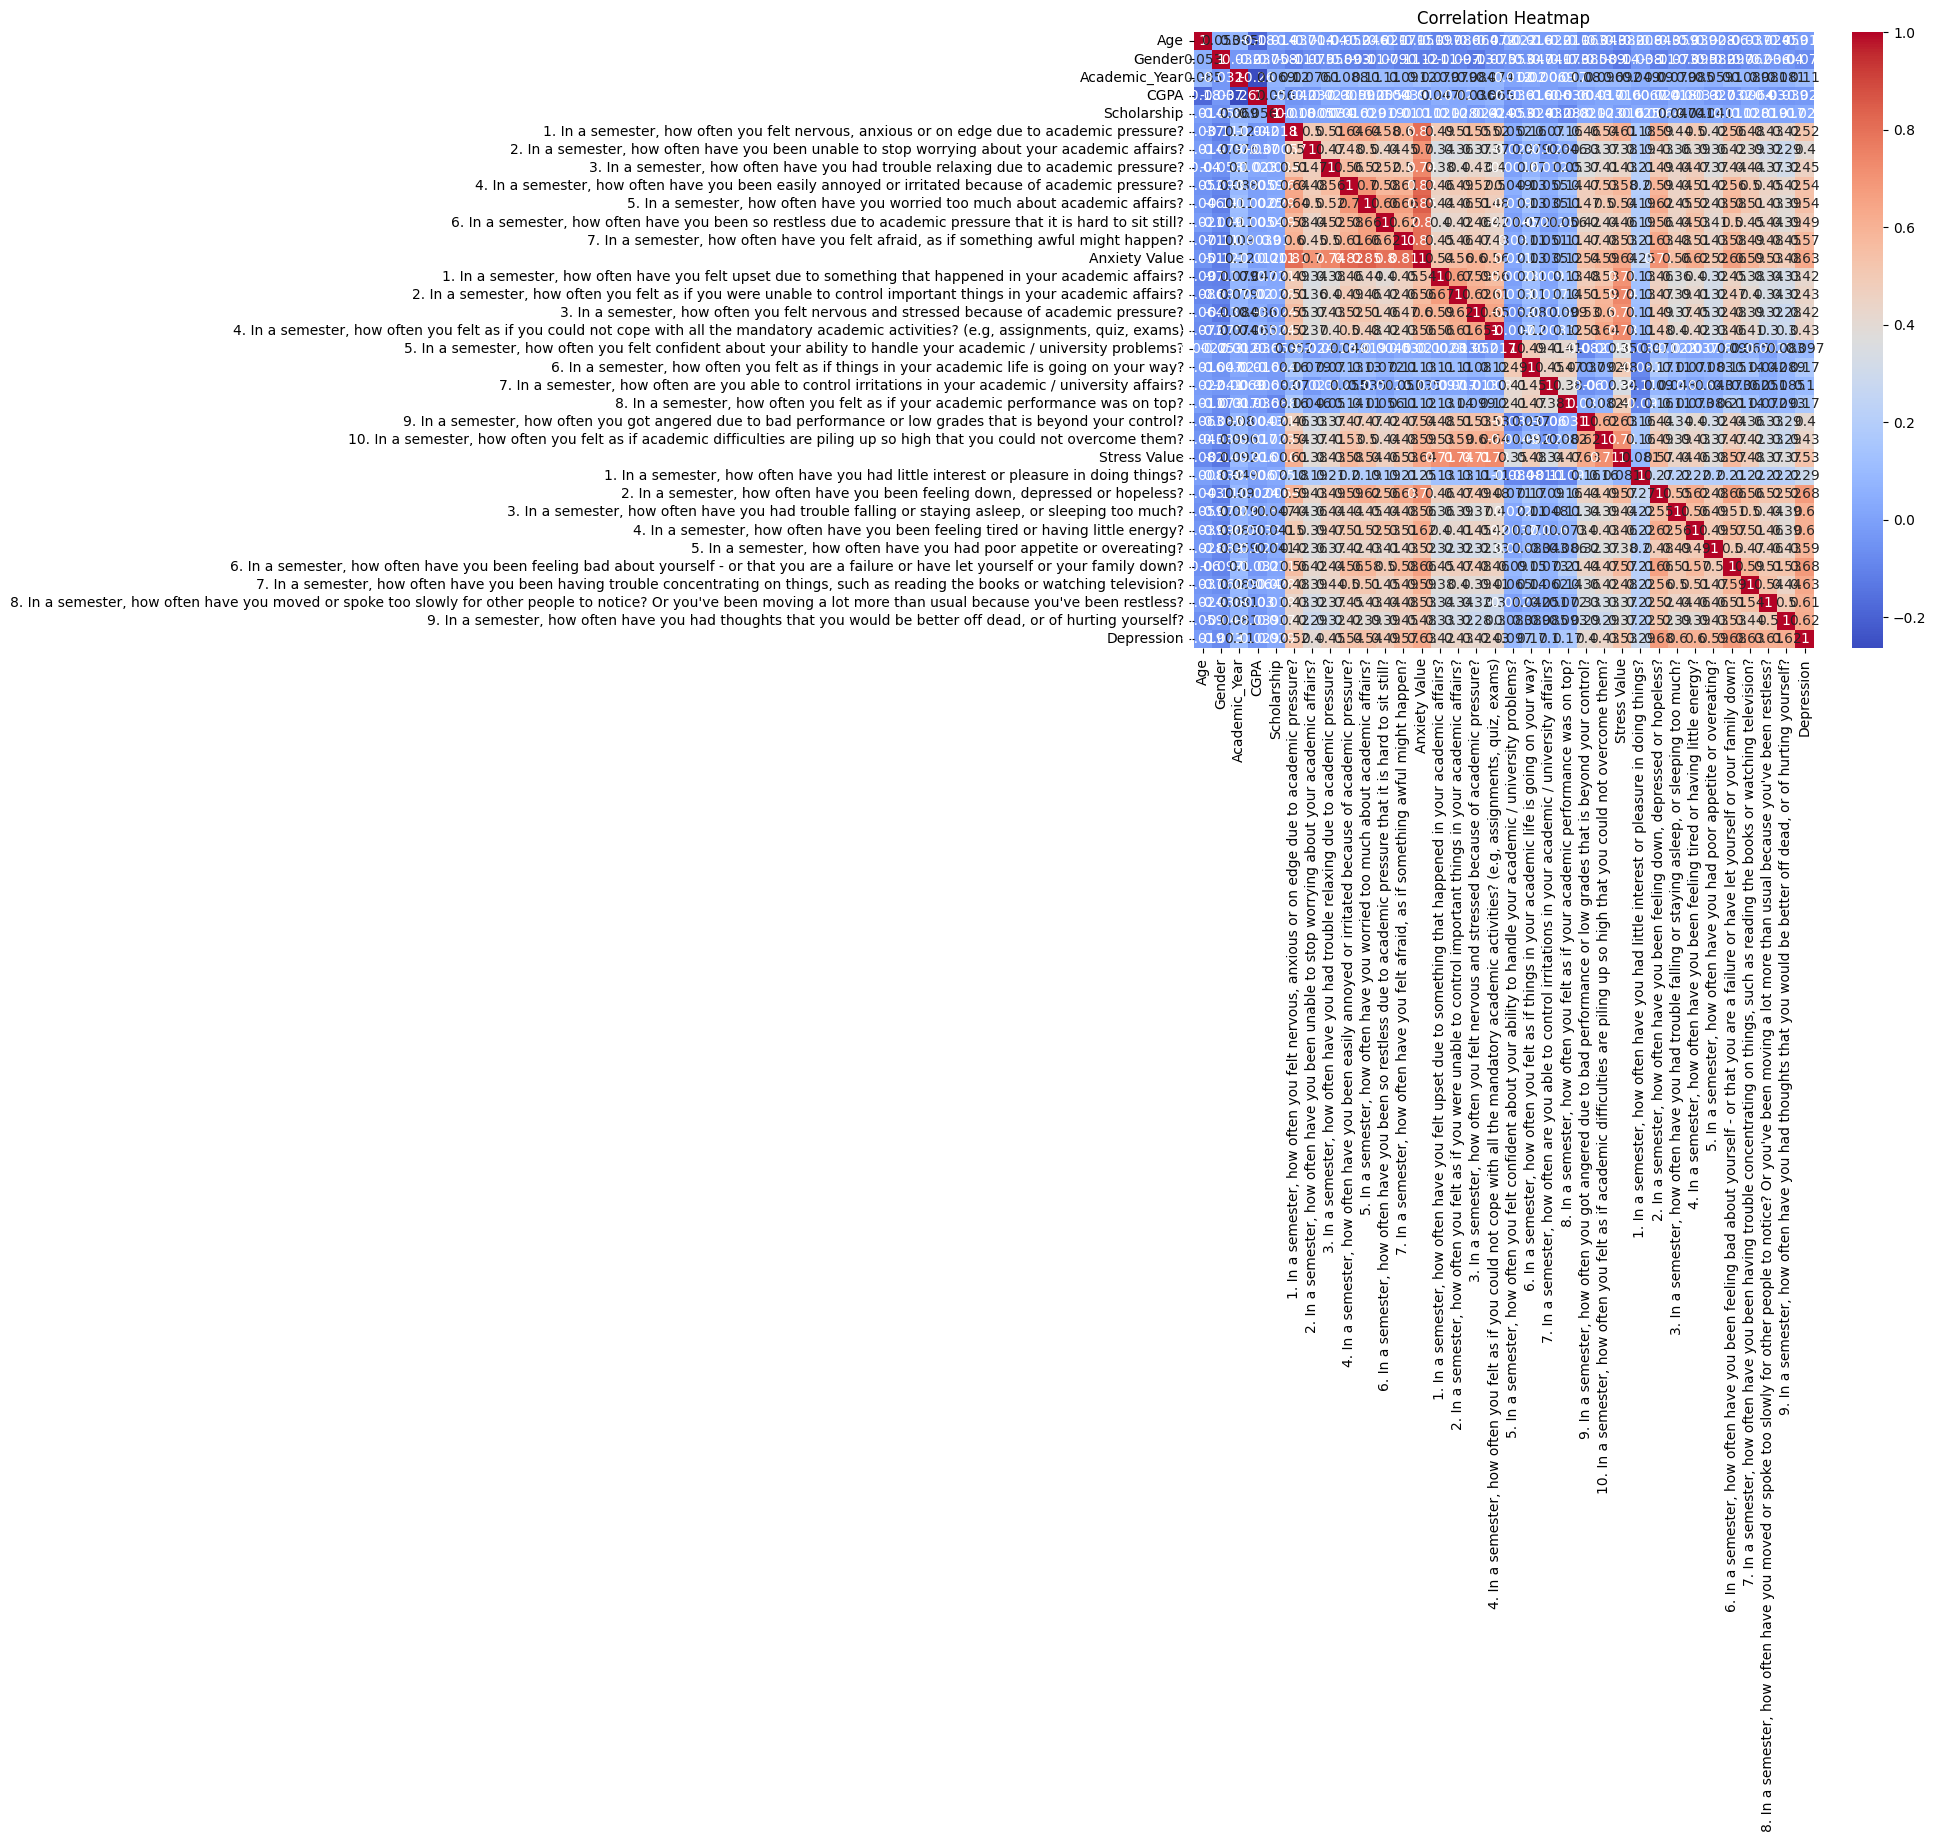

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('Depression', axis=1)
y = df['Depression']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [21]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
nn.fit(X_train, y_train)
nn_pred = nn.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "KNN": knn_pred,
    "Neural Network": nn_pred
}

for name, pred in models.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))


Logistic Regression
Accuracy: 0.9570707070707071
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        82
           1       0.75      0.67      0.71        18
           2       0.98      0.98      0.98        90
           3       0.99      0.97      0.98        99
           4       0.75      0.67      0.71         9
           5       0.97      1.00      0.98        98

    accuracy                           0.96       396
   macro avg       0.90      0.87      0.88       396
weighted avg       0.96      0.96      0.96       396


Decision Tree
Accuracy: 0.7348484848484849
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        82
           1       0.83      0.83      0.83        18
           2       0.68      0.60      0.64        90
           3       0.63      0.63      0.63        99
           4       1.00      1.00      1.00         9
           5       0.79      0.85     

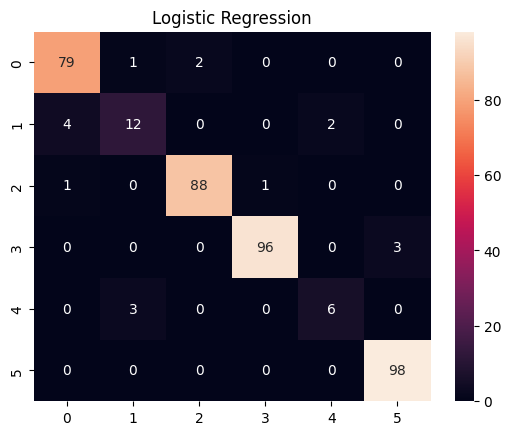

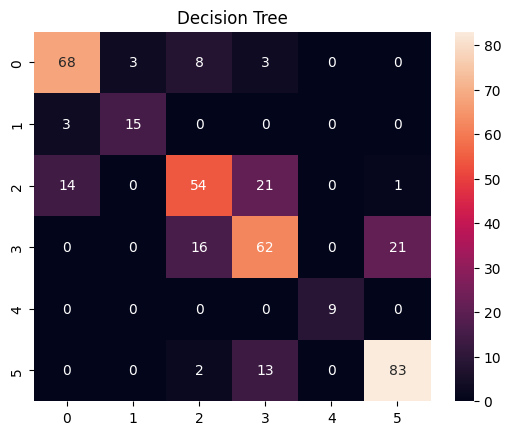

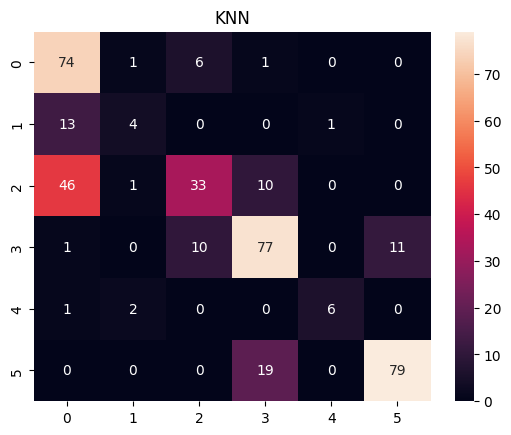

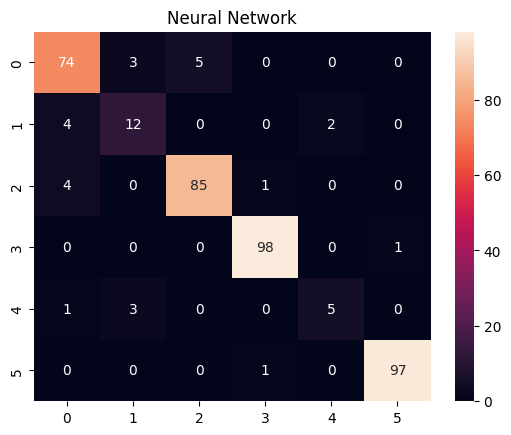

In [23]:
from sklearn.metrics import confusion_matrix

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True)
    plt.title(name)
    plt.show()

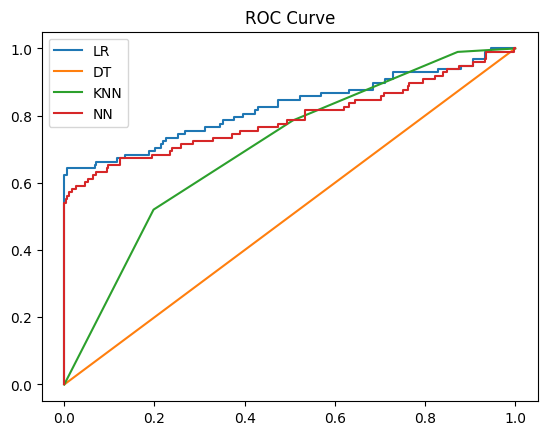

In [24]:
from sklearn.metrics import roc_curve, auc

plt.figure()

for model, name in zip([lr, dt, knn, nn], ["LR","DT","KNN","NN"]):
    prob = model.predict_proba(X_test)

    # for multi-class → take max probability
    prob = np.max(prob, axis=1)

    fpr, tpr, _ = roc_curve(y_test, prob, pos_label=y_test.max())
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve")
plt.show()

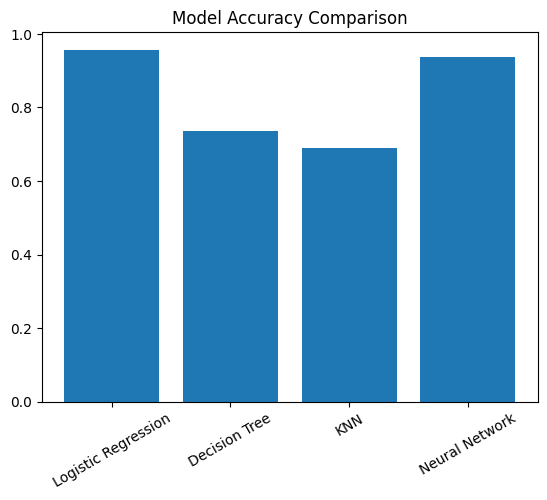

In [25]:
accuracies = [accuracy_score(y_test, p) for p in models.values()]
names = list(models.keys())

plt.bar(names, accuracies)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

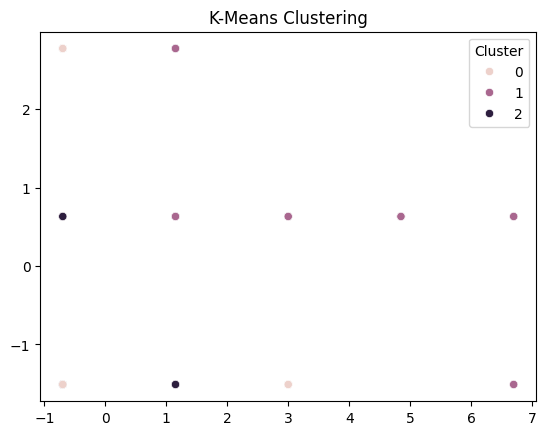

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=df['Cluster'])
plt.title("K-Means Clustering")
plt.show()